# Time Series Databases: Storing and Querying Time-Stamped Data

A **time series** is a sequence of data points recorded at successive points in time. Almost every system generates time series data: server CPU readings every 5 seconds, temperature sensors every minute, stock prices every millisecond, ML model predictions with latency logged on every call.

This notebook covers:
- What makes time series data different from regular relational data
- Generating and storing synthetic sensor data in DuckDB
- Core time series SQL patterns: range queries, downsampling, rolling averages, gap detection
- TimescaleDB concepts: hypertables, continuous aggregates, retention, compression
- InfluxDB concepts: line protocol, Flux, push vs pull
- When to use specialized databases vs DuckDB/PostgreSQL
- ML model monitoring with time series

## 1. What Makes Time Series Data Different

Time series data has four characteristics that strain traditional OLTP databases:

| Characteristic | Challenge | Time Series DB Solution |
|----------------|-----------|-------------------------|
| **High write throughput** | Thousands of inserts/sec | Columnar storage, batch ingestion |
| **Time-ordered queries** | Range scans are the primary access pattern | Time-based partitioning (chunks) |
| **Data retention** | Old data must be pruned automatically | Retention policies |
| **Downsampling** | Store raw data briefly, aggregates long-term | Continuous aggregates |

### Time Series vs OLTP vs OLAP

```
OLTP (PostgreSQL)     OLAP (DuckDB/Snowflake)    Time Series (TimescaleDB)
--------------------  -------------------------  -------------------------
Random reads/writes   Batch analytical reads     Sequential time-ordered writes
Row-oriented          Columnar                   Columnar + time partitioned
Normalize data        Denormalize for speed      Metric + tag model
Seconds of data       Years of data              Rolling window (retain N days)
B-tree indexes        Zone maps, Bloom filters   Time chunk indexes
```

### Use Cases
- **IoT sensor data**: temperature, pressure, humidity every 10 seconds from 10,000 devices
- **Server metrics**: CPU, memory, disk I/O from thousands of hosts (Prometheus)
- **Financial tick data**: bid/ask prices for thousands of instruments per second
- **ML model monitoring**: prediction latency, confidence scores, feature drift over time

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import random

print(f"DuckDB version: {duckdb.__version__}")
print(f"Pandas version: {pd.__version__}")
print()
print("DuckDB is an in-process analytical database (like SQLite for analytics).")
print("It handles time series SQL patterns excellently and is installed with pip.")
print("TimescaleDB and InfluxDB concepts are shown as SQL/syntax patterns.")

DuckDB version: 1.5.4
Pandas version: 2.3.3

DuckDB is an in-process analytical database (like SQLite for analytics).
It handles time series SQL patterns excellently and is installed with pip.
TimescaleDB and InfluxDB concepts are shown as SQL/syntax patterns.


## 2. Generating Synthetic Sensor Data

We generate 100,000 rows of synthetic sensor data: 5 sensors reading temperature and humidity every 30 seconds over several days, with realistic noise and occasional gaps.

In [2]:
random.seed(42)
np.random.seed(42)

# Parameters
N_SENSORS = 5
N_ROWS = 100_000
START_TIME = datetime(2026, 1, 1, 0, 0, 0)
INTERVAL_SECONDS = 30  # one reading every 30 seconds

# Base conditions per sensor (simulating sensors in different locations)
sensor_configs = {
    "SENSOR_01": {"base_temp": 22.0, "base_hum": 45.0, "location": "warehouse_A"},
    "SENSOR_02": {"base_temp": 18.5, "base_hum": 60.0, "location": "warehouse_B"},
    "SENSOR_03": {"base_temp": 25.0, "base_hum": 35.0, "location": "office_1"},
    "SENSOR_04": {"base_temp": 20.0, "base_hum": 55.0, "location": "server_room"},
    "SENSOR_05": {"base_temp": 16.0, "base_hum": 70.0, "location": "outdoor"},
}

rows_per_sensor = N_ROWS // N_SENSORS
records = []

for sensor_id, config in sensor_configs.items():
    for i in range(rows_per_sensor):
        ts = START_TIME + timedelta(seconds=i * INTERVAL_SECONDS)
        # Add daily cycle + random noise
        hour = ts.hour + ts.minute / 60.0
        daily_temp_cycle = 3.0 * np.sin(2 * np.pi * (hour - 6) / 24)
        daily_hum_cycle  = -5.0 * np.sin(2 * np.pi * (hour - 6) / 24)

        temperature = config["base_temp"] + daily_temp_cycle + np.random.normal(0, 0.5)
        humidity    = config["base_hum"]  + daily_hum_cycle  + np.random.normal(0, 1.5)
        humidity    = max(0, min(100, humidity))  # clamp 0-100

        records.append({
            "timestamp":   ts,
            "sensor_id":   sensor_id,
            "location":    config["location"],
            "temperature": round(temperature, 2),
            "humidity":    round(humidity, 2),
        })

df = pd.DataFrame(records)
print(f"Generated {len(df):,} rows across {N_SENSORS} sensors")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nSample rows:")
print(df.head(3).to_string(index=False))

Generated 100,000 rows across 5 sensors
Date range: 2026-01-01 00:00:00 to 2026-01-07 22:39:30

Sample rows:
          timestamp sensor_id    location  temperature  humidity
2026-01-01 00:00:00 SENSOR_01 warehouse_A        19.25     49.79
2026-01-01 00:00:30 SENSOR_01 warehouse_A        19.32     52.28
2026-01-01 00:01:00 SENSOR_01 warehouse_A        18.88     49.65


In [3]:
# Load into DuckDB (in-memory)
con = duckdb.connect(":memory:")

# Register the DataFrame and create a table
con.execute("""
    CREATE TABLE sensor_readings AS
    SELECT
        timestamp::TIMESTAMP AS timestamp,
        sensor_id::VARCHAR   AS sensor_id,
        location::VARCHAR    AS location,
        temperature::DOUBLE  AS temperature,
        humidity::DOUBLE     AS humidity
    FROM df
""")

# Verify
result = con.execute("SELECT COUNT(*) AS total_rows FROM sensor_readings").fetchone()
print(f"Rows in DuckDB: {result[0]:,}")

stats = con.execute("""
    SELECT
        sensor_id,
        COUNT(*) AS readings,
        ROUND(AVG(temperature), 2) AS avg_temp,
        ROUND(MIN(temperature), 2) AS min_temp,
        ROUND(MAX(temperature), 2) AS max_temp
    FROM sensor_readings
    GROUP BY sensor_id
    ORDER BY sensor_id
""").df()
print("\nPer-sensor statistics:")
print(stats.to_string(index=False))

Rows in DuckDB: 100,000

Per-sensor statistics:
sensor_id  readings  avg_temp  min_temp  max_temp
SENSOR_01     20000     22.02     17.27     26.80
SENSOR_02     20000     18.53     13.57     23.08
SENSOR_03     20000     25.03     20.36     29.55
SENSOR_04     20000     20.02     15.28     24.84
SENSOR_05     20000     16.03     11.33     20.70


## 3. Time Series Query Patterns in DuckDB

### Pattern 1: Range Queries

The most fundamental time series query: give me all data between two timestamps.

In [4]:
# Range query: one hour of data from SENSOR_01
range_result = con.execute("""
    SELECT timestamp, sensor_id, temperature, humidity
    FROM sensor_readings
    WHERE sensor_id = 'SENSOR_01'
      AND timestamp BETWEEN '2026-01-01 06:00:00' AND '2026-01-01 07:00:00'
    ORDER BY timestamp
""").df()

print(f"Range query returned {len(range_result)} rows (1 hour at 30s interval)")
print(range_result.head(5).to_string(index=False))

print("""
Time series optimization: time-based partitioning (TimescaleDB hypertable) means
this range query scans only the relevant time chunk, not the full table.
For 100M rows, the difference is seconds vs milliseconds.
""")

Range query returned 121 rows (1 hour at 30s interval)
          timestamp sensor_id  temperature  humidity
2026-01-01 06:00:00 SENSOR_01        22.33     46.76
2026-01-01 06:00:30 SENSOR_01        22.09     43.05
2026-01-01 06:01:00 SENSOR_01        22.21     44.00
2026-01-01 06:01:30 SENSOR_01        21.75     45.86
2026-01-01 06:02:00 SENSOR_01        22.65     44.99

Time series optimization: time-based partitioning (TimescaleDB hypertable) means
this range query scans only the relevant time chunk, not the full table.
For 100M rows, the difference is seconds vs milliseconds.



### Pattern 2: Downsampling (Time Bucketing)

In [5]:
# Downsample: 15-minute averages for SENSOR_01 over first day
# DuckDB uses time_bucket via date_trunc or epoch arithmetic
downsample = con.execute("""
    SELECT
        -- Group into 15-minute buckets (DuckDB syntax)
        epoch_ms(CAST(floor(epoch(timestamp) / 900) * 900000 AS BIGINT))::TIMESTAMP AS bucket_15min,
        sensor_id,
        ROUND(AVG(temperature), 3) AS avg_temp,
        ROUND(MIN(temperature), 3) AS min_temp,
        ROUND(MAX(temperature), 3) AS max_temp,
        COUNT(*) AS sample_count
    FROM sensor_readings
    WHERE sensor_id = 'SENSOR_01'
      AND timestamp < '2026-01-02'
    GROUP BY bucket_15min, sensor_id
    ORDER BY bucket_15min
    LIMIT 8
""").df()

print("15-minute downsampled data (first 8 buckets):")
print(downsample.to_string(index=False))

print("""
In TimescaleDB, this uses time_bucket():

  SELECT time_bucket('15 minutes', timestamp) AS bucket,
         AVG(temperature) AS avg_temp
  FROM sensor_readings
  WHERE sensor_id = 'SENSOR_01'
  GROUP BY bucket
  ORDER BY bucket;

Continuous aggregates in TimescaleDB pre-compute these -- the query above
runs instantly because the bucketed data is materialized automatically.
""")

15-minute downsampled data (first 8 buckets):
       bucket_15min sensor_id  avg_temp  min_temp  max_temp  sample_count
2026-01-01 00:00:00 SENSOR_01    18.930     18.14     19.79            30
2026-01-01 00:15:00 SENSOR_01    18.961     17.70     19.96            30
2026-01-01 00:30:00 SENSOR_01    19.004     18.23     19.98            30
2026-01-01 00:45:00 SENSOR_01    19.074     18.09     20.24            30
2026-01-01 01:00:00 SENSOR_01    19.207     17.50     20.21            30
2026-01-01 01:15:00 SENSOR_01    19.248     18.48     19.82            30
2026-01-01 01:30:00 SENSOR_01    19.299     18.19     20.34            30
2026-01-01 01:45:00 SENSOR_01    19.382     18.31     20.93            30

In TimescaleDB, this uses time_bucket():

  SELECT time_bucket('15 minutes', timestamp) AS bucket,
         AVG(temperature) AS avg_temp
  FROM sensor_readings
  WHERE sensor_id = 'SENSOR_01'
  GROUP BY bucket
  ORDER BY bucket;

Continuous aggregates in TimescaleDB pre-compute these --

### Pattern 3: Rolling Averages (Window Functions)

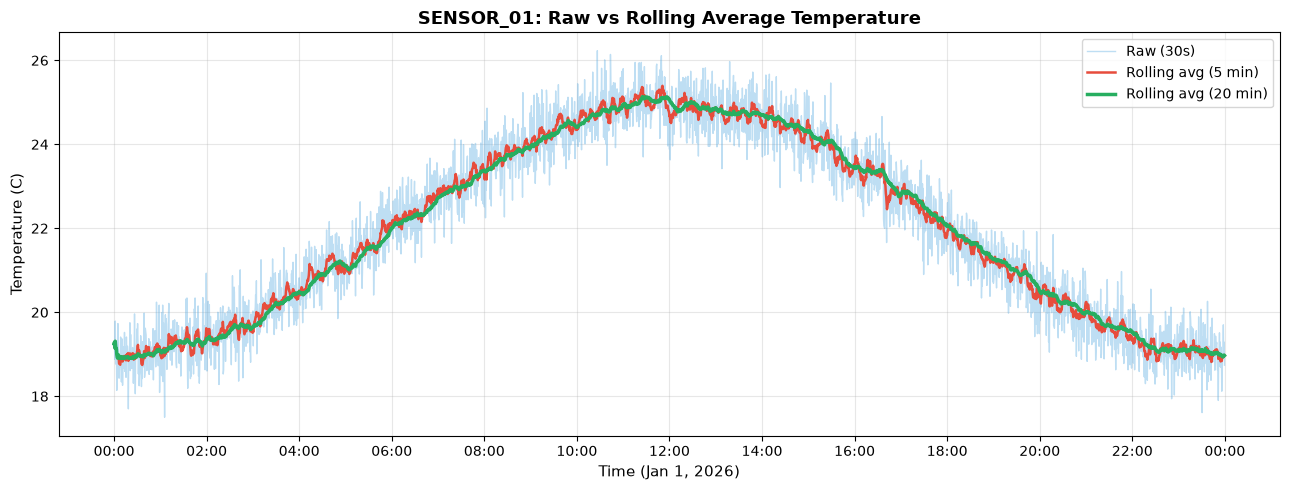

Rolling average data: 2,880 rows


In [6]:
# Rolling average: smooth temperature readings over a 10-point window
rolling = con.execute("""
    SELECT
        timestamp,
        temperature AS raw_temp,
        ROUND(AVG(temperature) OVER (
            PARTITION BY sensor_id
            ORDER BY timestamp
            ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
        ), 3) AS rolling_avg_10,
        ROUND(AVG(temperature) OVER (
            PARTITION BY sensor_id
            ORDER BY timestamp
            ROWS BETWEEN 39 PRECEDING AND CURRENT ROW
        ), 3) AS rolling_avg_40
    FROM sensor_readings
    WHERE sensor_id = 'SENSOR_01'
      AND timestamp < '2026-01-02'
    ORDER BY timestamp
""").df()

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rolling["timestamp"], rolling["raw_temp"],
        alpha=0.4, color="#5dade2", linewidth=1, label="Raw (30s)")
ax.plot(rolling["timestamp"], rolling["rolling_avg_10"],
        color="#e74c3c", linewidth=1.8, label="Rolling avg (5 min)")
ax.plot(rolling["timestamp"], rolling["rolling_avg_40"],
        color="#27ae60", linewidth=2.5, label="Rolling avg (20 min)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.set_xlabel("Time (Jan 1, 2026)", fontsize=11)
ax.set_ylabel("Temperature (C)", fontsize=11)
ax.set_title("SENSOR_01: Raw vs Rolling Average Temperature", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Rolling average data: {len(rolling):,} rows")

### Pattern 4: Gap Detection

In [7]:
# First create a sensor with artificial gaps
# Simulate dropping some readings (sensor offline)
con.execute("""
    CREATE TABLE sensor_with_gaps AS
    SELECT * FROM sensor_readings
    WHERE sensor_id = 'SENSOR_03'
      AND timestamp < '2026-01-03'
      -- Simulate gaps: drop readings between 08:00-09:30 on Jan 1 and 14:00-16:00 on Jan 2
      AND NOT (timestamp BETWEEN '2026-01-01 08:00:00' AND '2026-01-01 09:30:00')
      AND NOT (timestamp BETWEEN '2026-01-02 14:00:00' AND '2026-01-02 16:00:00')
""")

# Detect gaps: find consecutive readings more than 2 minutes apart
gaps = con.execute("""
    SELECT
        sensor_id,
        prev_ts AS gap_start,
        curr_ts AS gap_end,
        ROUND(gap_minutes, 1) AS gap_minutes
    FROM (
        SELECT
            sensor_id,
            LAG(timestamp) OVER (PARTITION BY sensor_id ORDER BY timestamp) AS prev_ts,
            timestamp AS curr_ts,
            EPOCH(timestamp - LAG(timestamp) OVER
                  (PARTITION BY sensor_id ORDER BY timestamp)) / 60.0 AS gap_minutes
        FROM sensor_with_gaps
    ) t
    WHERE gap_minutes > 2.0
    ORDER BY gap_start
""").df()

print("Gaps detected (periods with no readings > 2 minutes):")
for _, row in gaps.iterrows():
    print(f"  {row['sensor_id']}: {row['gap_start']} to {row['gap_end']}  ({row['gap_minutes']} min)")

Gaps detected (periods with no readings > 2 minutes):
  SENSOR_03: 2026-01-01 07:59:30 to 2026-01-01 09:30:30  (91.0 min)
  SENSOR_03: 2026-01-02 13:59:30 to 2026-01-02 16:00:30  (121.0 min)


### Pattern 5: Latest Value Per Sensor

In [8]:
# Get the latest reading for each sensor (dashboard view)
latest = con.execute("""
    SELECT timestamp, sensor_id, location, temperature, humidity
    FROM (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY sensor_id
                ORDER BY timestamp DESC
            ) AS rn
        FROM sensor_readings
    ) ranked
    WHERE rn = 1
    ORDER BY sensor_id
""").df()

print("Latest reading per sensor (QUALIFY / ROW_NUMBER pattern):")
print(latest.to_string(index=False))

print("""
DuckDB also supports QUALIFY directly:

  SELECT *
  FROM sensor_readings
  QUALIFY ROW_NUMBER() OVER (PARTITION BY sensor_id ORDER BY timestamp DESC) = 1
  ORDER BY sensor_id;

This is more concise and avoids the subquery.
""")

Latest reading per sensor (QUALIFY / ROW_NUMBER pattern):
          timestamp sensor_id    location  temperature  humidity
2026-01-07 22:39:30 SENSOR_01 warehouse_A        19.59     50.22
2026-01-07 22:39:30 SENSOR_02 warehouse_B        15.68     63.20
2026-01-07 22:39:30 SENSOR_03    office_1        21.88     40.04
2026-01-07 22:39:30 SENSOR_04 server_room        17.04     60.79
2026-01-07 22:39:30 SENSOR_05     outdoor        13.61     73.09

DuckDB also supports QUALIFY directly:

  SELECT *
  FROM sensor_readings
  QUALIFY ROW_NUMBER() OVER (PARTITION BY sensor_id ORDER BY timestamp DESC) = 1
  ORDER BY sensor_id;

This is more concise and avoids the subquery.



## 4. TimescaleDB: PostgreSQL for Time Series

TimescaleDB is a PostgreSQL extension that adds time series capabilities while keeping full SQL compatibility. You interact with it exactly like PostgreSQL -- the extension handles optimization transparently.

### Hypertables: Automatic Time Partitioning

A hypertable is a regular PostgreSQL table that TimescaleDB automatically partitions into **chunks** by time (and optionally by a space dimension like `sensor_id`).

In [9]:
# TimescaleDB concepts -- shown as SQL with explanations
# (TimescaleDB is a PostgreSQL extension, not available as a Python package)

timescaledb_setup = """
-- 1. Create a regular table
CREATE TABLE sensor_readings (
    timestamp   TIMESTAMPTZ NOT NULL,
    sensor_id   TEXT        NOT NULL,
    location    TEXT,
    temperature DOUBLE PRECISION,
    humidity    DOUBLE PRECISION
);

-- 2. Convert to hypertable (this is the only TimescaleDB-specific step!)
--    TimescaleDB automatically creates chunks by time
SELECT create_hypertable('sensor_readings', 'timestamp',
    chunk_time_interval => INTERVAL '1 day',
    partitioning_column => 'sensor_id',
    number_partitions   => 4
);

-- After this, ALL your existing SQL queries work unchanged.
-- TimescaleDB optimizes range scans, downsampling, and latest-value queries
-- by routing them to only the relevant chunks.
"""

print("TimescaleDB Hypertable Setup:")
print(timescaledb_setup)

TimescaleDB Hypertable Setup:

-- 1. Create a regular table
CREATE TABLE sensor_readings (
    timestamp   TIMESTAMPTZ NOT NULL,
    sensor_id   TEXT        NOT NULL,
    location    TEXT,
    temperature DOUBLE PRECISION,
    humidity    DOUBLE PRECISION
);

-- 2. Convert to hypertable (this is the only TimescaleDB-specific step!)
--    TimescaleDB automatically creates chunks by time
SELECT create_hypertable('sensor_readings', 'timestamp',
    chunk_time_interval => INTERVAL '1 day',
    partitioning_column => 'sensor_id',
    number_partitions   => 4
);

-- After this, ALL your existing SQL queries work unchanged.
-- TimescaleDB optimizes range scans, downsampling, and latest-value queries
-- by routing them to only the relevant chunks.



In [10]:
# TimescaleDB Continuous Aggregates
continuous_agg = """
-- Continuous aggregates: materialized, auto-refreshed downsampled views
-- TimescaleDB maintains these automatically as new data arrives

CREATE MATERIALIZED VIEW sensor_readings_15min
WITH (timescaledb.continuous) AS
SELECT
    time_bucket('15 minutes', timestamp) AS bucket,
    sensor_id,
    AVG(temperature) AS avg_temp,
    MIN(temperature) AS min_temp,
    MAX(temperature) AS max_temp,
    AVG(humidity)    AS avg_humidity,
    COUNT(*)         AS sample_count
FROM sensor_readings
GROUP BY bucket, sensor_id
WITH NO DATA;

-- Set up automatic refresh: update every 5 minutes, look back 1 hour
SELECT add_continuous_aggregate_policy('sensor_readings_15min',
    start_offset => INTERVAL '1 hour',
    end_offset   => INTERVAL '5 minutes',
    schedule_interval => INTERVAL '5 minutes'
);

-- Now queries against the view are instant (pre-computed):
SELECT bucket, avg_temp
FROM sensor_readings_15min
WHERE sensor_id = 'SENSOR_01'
  AND bucket > NOW() - INTERVAL '24 hours'
ORDER BY bucket;
"""

print("TimescaleDB Continuous Aggregates:")
print(continuous_agg)

TimescaleDB Continuous Aggregates:

-- Continuous aggregates: materialized, auto-refreshed downsampled views
-- TimescaleDB maintains these automatically as new data arrives

CREATE MATERIALIZED VIEW sensor_readings_15min
WITH (timescaledb.continuous) AS
SELECT
    time_bucket('15 minutes', timestamp) AS bucket,
    sensor_id,
    AVG(temperature) AS avg_temp,
    MIN(temperature) AS min_temp,
    MAX(temperature) AS max_temp,
    AVG(humidity)    AS avg_humidity,
    COUNT(*)         AS sample_count
FROM sensor_readings
GROUP BY bucket, sensor_id
WITH NO DATA;

-- Set up automatic refresh: update every 5 minutes, look back 1 hour
SELECT add_continuous_aggregate_policy('sensor_readings_15min',
    start_offset => INTERVAL '1 hour',
    end_offset   => INTERVAL '5 minutes',
    schedule_interval => INTERVAL '5 minutes'
);

-- Now queries against the view are instant (pre-computed):
SELECT bucket, avg_temp
FROM sensor_readings_15min
WHERE sensor_id = 'SENSOR_01'
  AND bucket > NOW() - IN

In [11]:
# TimescaleDB Retention and Compression
retention_compression = """
-- Retention policy: auto-delete data older than 90 days
SELECT add_retention_policy('sensor_readings',
    INTERVAL '90 days'
);

-- Compression: compress chunks older than 7 days (columnar, 10-20x smaller)
ALTER TABLE sensor_readings SET (
    timescaledb.compress,
    timescaledb.compress_segmentby = 'sensor_id',
    timescaledb.compress_orderby   = 'timestamp DESC'
);

SELECT add_compression_policy('sensor_readings',
    INTERVAL '7 days'
);

-- Check compression stats
SELECT
    chunk_schema,
    chunk_name,
    pg_size_pretty(before_compression_total_bytes) AS before,
    pg_size_pretty(after_compression_total_bytes)  AS after,
    compression_ratio
FROM chunk_compression_stats('sensor_readings');
"""
print("TimescaleDB Retention and Compression:")
print(retention_compression)

TimescaleDB Retention and Compression:

-- Retention policy: auto-delete data older than 90 days
SELECT add_retention_policy('sensor_readings',
    INTERVAL '90 days'
);

-- Compression: compress chunks older than 7 days (columnar, 10-20x smaller)
ALTER TABLE sensor_readings SET (
    timescaledb.compress,
    timescaledb.compress_segmentby = 'sensor_id',
    timescaledb.compress_orderby   = 'timestamp DESC'
);

SELECT add_compression_policy('sensor_readings',
    INTERVAL '7 days'
);

-- Check compression stats
SELECT
    chunk_schema,
    chunk_name,
    pg_size_pretty(before_compression_total_bytes) AS before,
    pg_size_pretty(after_compression_total_bytes)  AS after,
    compression_ratio
FROM chunk_compression_stats('sensor_readings');



## 5. InfluxDB: Purpose-Built Time Series

InfluxDB is a dedicated time series database with its own data model and query language. It uses a **metric + tags** model rather than SQL tables.

### The Line Protocol Format

InfluxDB ingests data in **line protocol**: a compact text format designed for high-throughput writes.

```
measurement,tag_key=tag_value field_key=field_value timestamp
```

- **measurement**: like a table name
- **tags**: indexed metadata (low cardinality) -- sensor_id, location
- **fields**: actual measurements (numeric or string)
- **timestamp**: Unix nanoseconds (optional, defaults to now)

In [12]:
# InfluxDB concepts
print("InfluxDB Line Protocol examples:")
print()

# Generate some line protocol format data
sample_rows = df[df["sensor_id"] == "SENSOR_01"].head(3)
for _, row in sample_rows.iterrows():
    ts_ns = int(row["timestamp"].timestamp() * 1e9)
    line = (f"sensor_readings,sensor_id={row['sensor_id']},location={row['location']} "
            f"temperature={row['temperature']},humidity={row['humidity']} {ts_ns}")
    print(f"  {line}")

print()
influxdb_example = """
# InfluxDB Python client (influxdb-client package)
from influxdb_client import InfluxDBClient, Point
from influxdb_client.client.write_api import SYNCHRONOUS

client = InfluxDBClient(url="http://localhost:8086",
                        token="your-token",
                        org="your-org")
write_api = client.write_api(write_options=SYNCHRONOUS)

# Write a single point
point = (
    Point("sensor_readings")
    .tag("sensor_id", "SENSOR_01")
    .tag("location", "warehouse_A")
    .field("temperature", 22.3)
    .field("humidity", 45.1)
)
write_api.write(bucket="sensors", record=point)

# Flux query: mean temperature by 15-minute window
query = '''
from(bucket: "sensors")
  |> range(start: -24h)
  |> filter(fn: (r) => r._measurement == "sensor_readings")
  |> filter(fn: (r) => r.sensor_id == "SENSOR_01")
  |> filter(fn: (r) => r._field == "temperature")
  |> aggregateWindow(every: 15m, fn: mean, createEmpty: false)
  |> yield(name: "mean")
'''
result = client.query_api().query(query)
"""
print("InfluxDB Python client pattern:")
print(influxdb_example)

InfluxDB Line Protocol examples:

  sensor_readings,sensor_id=SENSOR_01,location=warehouse_A temperature=19.25,humidity=49.79 1767225600000000000
  sensor_readings,sensor_id=SENSOR_01,location=warehouse_A temperature=19.32,humidity=52.28 1767225630000000000
  sensor_readings,sensor_id=SENSOR_01,location=warehouse_A temperature=18.88,humidity=49.65 1767225660000000000

InfluxDB Python client pattern:

# InfluxDB Python client (influxdb-client package)
from influxdb_client import InfluxDBClient, Point
from influxdb_client.client.write_api import SYNCHRONOUS

client = InfluxDBClient(url="http://localhost:8086",
                        token="your-token",
                        org="your-org")
write_api = client.write_api(write_options=SYNCHRONOUS)

# Write a single point
point = (
    Point("sensor_readings")
    .tag("sensor_id", "SENSOR_01")
    .tag("location", "warehouse_A")
    .field("temperature", 22.3)
    .field("humidity", 45.1)
)
write_api.write(bucket="sensors", record=point)

In [13]:
# InfluxDB vs InfluxQL vs Flux
print("InfluxQL (SQL-like, legacy):")
print("""
  SELECT MEAN(temperature)
  FROM sensor_readings
  WHERE sensor_id = 'SENSOR_01'
    AND time > now() - 24h
  GROUP BY time(15m)
""")

print("Flux (functional pipeline, modern InfluxDB 2.x):")
print("""
  from(bucket: "sensors")
    |> range(start: -24h)
    |> filter(fn: (r) => r.sensor_id == "SENSOR_01")
    |> filter(fn: (r) => r._field == "temperature")
    |> aggregateWindow(every: 15m, fn: mean)
""")

print("Key InfluxDB concepts:")
concepts = [
    ("Tags vs Fields",       "Tags are indexed (low cardinality); fields are not indexed (measurements)"),
    ("Bucket",               "Storage unit with a retention policy (like a database + retention in one)"),
    ("Push model",           "Applications push data to InfluxDB (POST /api/v2/write)"),
    ("Prometheus pull model","Prometheus scrapes /metrics endpoint; pushes to InfluxDB via remote_write"),
    ("Downsampling tasks",   "Flux tasks aggregate raw data into coarser buckets automatically"),
]
for concept, desc in concepts:
    print(f"  {concept}: {desc}")

InfluxQL (SQL-like, legacy):

  SELECT MEAN(temperature)
  FROM sensor_readings
  WHERE sensor_id = 'SENSOR_01'
    AND time > now() - 24h
  GROUP BY time(15m)

Flux (functional pipeline, modern InfluxDB 2.x):

  from(bucket: "sensors")
    |> range(start: -24h)
    |> filter(fn: (r) => r.sensor_id == "SENSOR_01")
    |> filter(fn: (r) => r._field == "temperature")
    |> aggregateWindow(every: 15m, fn: mean)

Key InfluxDB concepts:
  Tags vs Fields: Tags are indexed (low cardinality); fields are not indexed (measurements)
  Bucket: Storage unit with a retention policy (like a database + retention in one)
  Push model: Applications push data to InfluxDB (POST /api/v2/write)
  Prometheus pull model: Prometheus scrapes /metrics endpoint; pushes to InfluxDB via remote_write
  Downsampling tasks: Flux tasks aggregate raw data into coarser buckets automatically


## 6. ML Model Monitoring with Time Series

Machine learning models in production degrade over time as the real-world distribution shifts away from training data. Time series databases are the natural home for **model monitoring** metrics.

In [14]:
# Simulate ML model monitoring data
np.random.seed(99)

# Generate 30 days of model metrics (logged every 5 minutes)
monitor_start = datetime(2026, 1, 1)
n_monitor_rows = 30 * 24 * 12  # 30 days, every 5 min

timestamps = [monitor_start + timedelta(minutes=5 * i) for i in range(n_monitor_rows)]

# Simulate model drift: accuracy degrades over 30 days
days_elapsed = np.array([(t - monitor_start).days for t in timestamps])
base_accuracy = 0.92
drift = days_elapsed * 0.003  # 0.3% per day degradation

monitor_df = pd.DataFrame({
    "timestamp":           timestamps,
    "model_id":            "fraud_classifier_v2",
    "accuracy":            np.clip(base_accuracy - drift + np.random.normal(0, 0.01, n_monitor_rows), 0.5, 0.99),
    "latency_ms":          50 + np.random.exponential(10, n_monitor_rows) + days_elapsed * 0.5,
    "prediction_volume":   (500 + 100 * np.sin(2 * np.pi * days_elapsed / 7)
                           + np.random.normal(0, 30, n_monitor_rows)).astype(int),
    "feature_drift_score": np.clip(0.05 + days_elapsed * 0.004 + np.random.normal(0, 0.01, n_monitor_rows), 0, 1),
})

print(f"Model monitoring data: {len(monitor_df):,} rows (30 days at 5-min intervals)")

# Load into DuckDB
con.execute("""
    CREATE TABLE model_metrics AS SELECT * FROM monitor_df
""")

print("\nModel monitoring schema:")
print("  timestamp, model_id, accuracy, latency_ms, prediction_volume, feature_drift_score")
print(f"\nFirst row: {monitor_df.iloc[0].to_dict()}")

Model monitoring data: 8,640 rows (30 days at 5-min intervals)

Model monitoring schema:
  timestamp, model_id, accuracy, latency_ms, prediction_volume, feature_drift_score

First row: {'timestamp': Timestamp('2026-01-01 00:00:00'), 'model_id': 'fraud_classifier_v2', 'accuracy': 0.9185764115729805, 'latency_ms': 59.27862352340154, 'prediction_volume': 472, 'feature_drift_score': 0.04077921930848929}


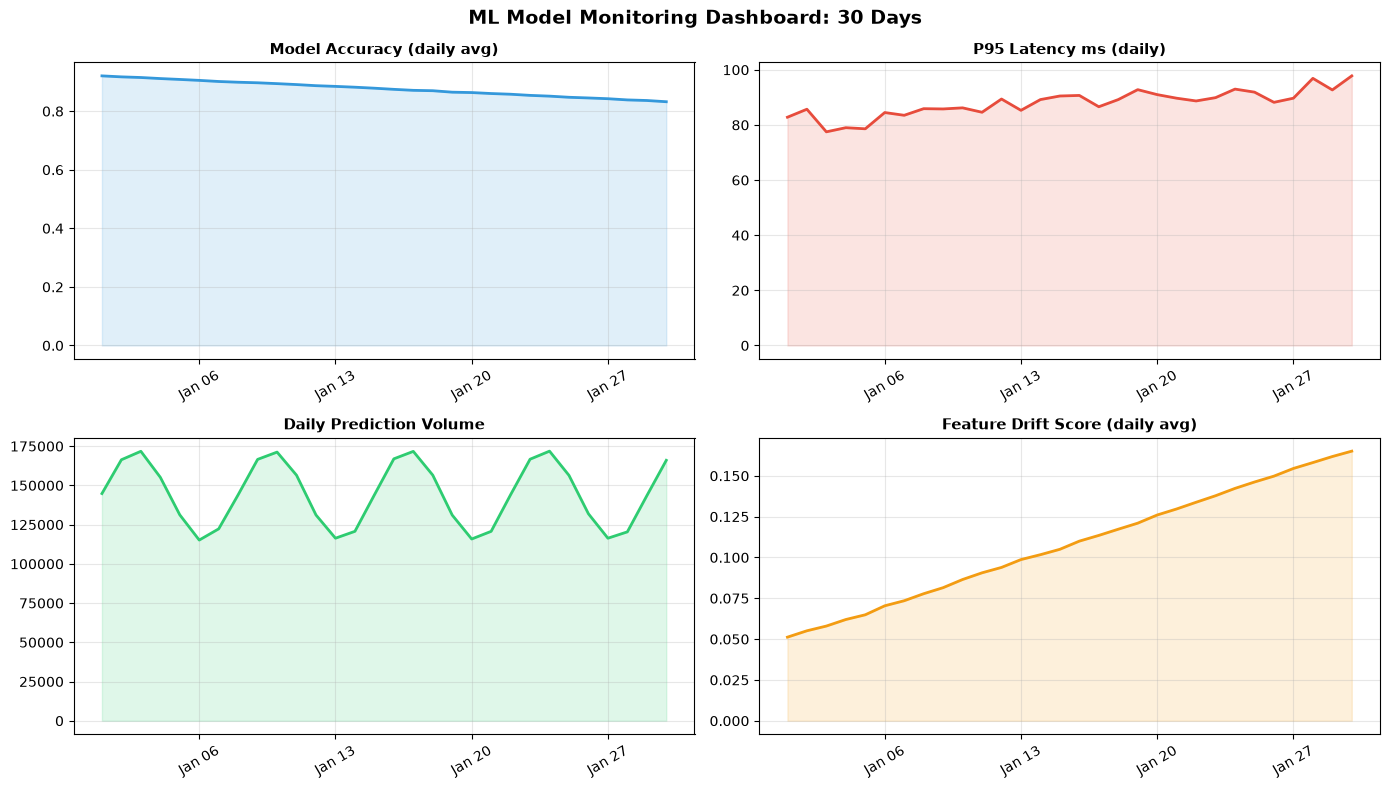

Accuracy trend: 0.9206 -> 0.8323
Drift score trend: 0.0512 -> 0.1651


In [15]:
# Query: daily rollup for model monitoring
daily_metrics = con.execute("""
    SELECT
        DATE_TRUNC('day', timestamp) AS day,
        ROUND(AVG(accuracy), 4)            AS avg_accuracy,
        ROUND(PERCENTILE_CONT(0.95)
              WITHIN GROUP (ORDER BY latency_ms), 1) AS p95_latency_ms,
        SUM(prediction_volume)             AS total_predictions,
        ROUND(AVG(feature_drift_score), 4) AS avg_drift_score
    FROM model_metrics
    GROUP BY day
    ORDER BY day
""").df()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = [
    ("avg_accuracy",     "Model Accuracy (daily avg)",       axes[0][0], "#3498db"),
    ("p95_latency_ms",   "P95 Latency ms (daily)",           axes[0][1], "#e74c3c"),
    ("total_predictions","Daily Prediction Volume",          axes[1][0], "#2ecc71"),
    ("avg_drift_score",  "Feature Drift Score (daily avg)",  axes[1][1], "#f39c12"),
]
for col, title, ax, color in metrics:
    ax.plot(daily_metrics["day"], daily_metrics[col], color=color, linewidth=2)
    ax.fill_between(daily_metrics["day"], daily_metrics[col], alpha=0.15, color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("ML Model Monitoring Dashboard: 30 Days", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Accuracy trend:", round(daily_metrics["avg_accuracy"].iloc[0], 4),
      "->", round(daily_metrics["avg_accuracy"].iloc[-1], 4))
print("Drift score trend:", round(daily_metrics["avg_drift_score"].iloc[0], 4),
      "->", round(daily_metrics["avg_drift_score"].iloc[-1], 4))

## 7. When to Use Which Database

| Requirement | Best Choice | Why |
|-------------|-------------|-----|
| IoT, 10k+ sensors, high-frequency writes | TimescaleDB or InfluxDB | Chunk-based ingestion, retention policies |
| Analytics on time series, SQL team | DuckDB or TimescaleDB | Full SQL, excellent analytical performance |
| Application metrics, pull model | Prometheus + Grafana | Pull scraping, alert rules, standard ecosystem |
| ML monitoring (structured) | TimescaleDB or DuckDB | SQL for aggregations and alerting |
| Financial tick data | TimescaleDB (compressed) | High compression, SQL OHLCV queries |
| Prototype / < 1M rows | DuckDB | Zero setup, installed via pip |

### Prometheus for ML Monitoring

Prometheus uses a **pull model**: it scrapes your application's `/metrics` endpoint and stores time series. Your ML service exposes:

```python
from prometheus_client import Histogram, Gauge, start_http_server

prediction_latency = Histogram('model_predict_latency_seconds',
                               'Time to generate a prediction')
model_accuracy     = Gauge('model_accuracy_last_hour',
                           'Rolling accuracy over last hour')

# In your prediction handler:
with prediction_latency.time():
    result = model.predict(features)
```

Grafana then queries Prometheus to build monitoring dashboards and alert when accuracy drops below a threshold.

In [16]:
# Final comparison: query performance concept
print("Time Series Database Comparison\n" + "=" * 50)

comparison = [
    ("TimescaleDB",  "PostgreSQL extension", "SQL (time_bucket, TSDB functions)", "Very high",    "Hypertables + columnar compression",  "IoT, financial data, ML monitoring"),
    ("InfluxDB",     "Dedicated TSDB",        "Flux / InfluxQL",                   "Very high",    "TSM engine (columnar)",               "DevOps metrics, IoT push model"),
    ("DuckDB",       "In-process analytics", "SQL (full standard)",               "High",         "Columnar, no time partitioning",       "Analytics, prototyping, < 50M rows"),
    ("Prometheus",   "Pull-based metrics",   "PromQL",                            "Medium",       "Custom TSDB, 2-byte resolution",       "Infrastructure and app metrics"),
    ("PostgreSQL",   "General purpose RDBMS", "SQL",                              "Low-Medium",   "Row-oriented, manual partitioning",   "Low-volume TS with relational joins"),
]

print(f"{'Database':<15} {'Type':<25} {'Query Lang':<22} {'Write Throughput':<18} {'Storage':<35} {'Best For'}")
print("-" * 140)
for row in comparison:
    print(f"{row[0]:<15} {row[1]:<25} {row[2]:<22} {row[3]:<18} {row[4]:<35} {row[5]}")

Time Series Database Comparison
Database        Type                      Query Lang             Write Throughput   Storage                             Best For
--------------------------------------------------------------------------------------------------------------------------------------------
TimescaleDB     PostgreSQL extension      SQL (time_bucket, TSDB functions) Very high          Hypertables + columnar compression  IoT, financial data, ML monitoring
InfluxDB        Dedicated TSDB            Flux / InfluxQL        Very high          TSM engine (columnar)               DevOps metrics, IoT push model
DuckDB          In-process analytics      SQL (full standard)    High               Columnar, no time partitioning      Analytics, prototyping, < 50M rows
Prometheus      Pull-based metrics        PromQL                 Medium             Custom TSDB, 2-byte resolution      Infrastructure and app metrics
PostgreSQL      General purpose RDBMS     SQL                    Low-Medium

## Key Takeaways

1. **Time series data is write-heavy and time-ordered** -- the dominant access pattern is range queries by time, not random lookups. This makes time-based partitioning and columnar compression essential.

2. **DuckDB handles time series SQL excellently** -- for analytics up to tens of millions of rows, DuckDB with standard SQL window functions, `DATE_TRUNC`, and `QUALIFY` covers most use cases without any additional infrastructure.

3. **TimescaleDB is PostgreSQL + time series** -- one `create_hypertable()` call turns any table into a partitioned, compressed, retention-managed time series store. Your team keeps all its SQL knowledge.

4. **InfluxDB uses a push model and line protocol** -- designed for high-throughput metric ingestion from many sources. Its tag/field distinction (indexed vs not indexed) is critical for cardinality management.

5. **Continuous aggregates eliminate downsampling overhead** -- TimescaleDB maintains pre-computed bucketed views automatically. A query for hourly averages over a year runs in milliseconds.

6. **Retention policies and compression are first-class features** -- time series databases auto-delete old data and compress historical chunks. Raw sensor data compresses 10-20x in columnar format.

7. **ML model monitoring is a time series problem** -- log predictions, latency, and feature distributions as time series. Query for drift, alert when metrics cross thresholds. Prometheus + Grafana is the standard stack for infrastructure monitoring; TimescaleDB is better for custom ML metrics with SQL alerting.